# Проект: семантический поиск товаров по текстовому запросу

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [77]:
# Устанавливаем зафиксированные версии в окружении
from pathlib import Path

requirements_path = Path("requirements.txt")
if not requirements_path.exists():
    requirements_path = Path("ProjectMonth") / "requirements.txt"

%pip install -r {requirements_path}


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.


In [78]:
# Импорты для загрузки данных, анализа, поиска и сохранения экспериментов.
import html
import os
import random
import re
from pathlib import Path
from time import perf_counter

import boto3
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from IPython.display import display
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


In [79]:
# Компактный вывод таблиц; длинные описания показываем отдельно.
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="muted")


**Настройки воспроизводимости.** Во всех случайных операциях используется `SEED = 42`. Для графиков выбран seaborn с общей темой, чтобы таблицы и распределения было удобно сопоставлять.


In [80]:
# Один seed для всех случайных операций.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [81]:
# Пути к данным и результатам.
PROJECT_DIR = Path.cwd()
if (PROJECT_DIR / "ProjectMonth").is_dir():
    PROJECT_DIR = PROJECT_DIR / "ProjectMonth"
FILES_DIR = PROJECT_DIR / "files"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
FILES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)
load_dotenv(PROJECT_DIR / ".env")


True

In [82]:
RAW_PRODUCTS_PATH = FILES_DIR / "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = FILES_DIR / "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = FILES_DIR / "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = FILES_DIR / "queries_synthetic_test.parquet"


In [83]:
# Подключение к S3. Ключи хранятся в .env.
s3 = boto3.client(
    "s3",
    endpoint_url=os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net"),
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name="ru-central1",
)


In [84]:
# Существующие файлы повторно не скачиваем.
for path in [RAW_PRODUCTS_PATH, ASSESSED_POOL_PATH, TRAIN_QUERIES_PATH, TEST_QUERIES_PATH]:
    if path.exists() and path.stat().st_size > 0: # проверка что файл существует и не пустой
        print("Уже скачан:", path.name)
    else:
        temporary_path = path.with_suffix(".parquet.part") # временный файл, чтобы не оставлять пустой файл при прерывании скачивания
        s3.download_file("s3-ds-source", path.name, str(temporary_path))
        temporary_path.replace(path)
        print("Скачан:", path.name)


Уже скачан: wb_products_raw_sample.parquet
Уже скачан: wb_products_dedup.parquet
Уже скачан: queries_synthetic_train.parquet
Уже скачан: queries_synthetic_test.parquet


---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [85]:
# Загрузка данных в датафреймы pandas
df_raw = pd.read_parquet(RAW_PRODUCTS_PATH)
queries_train = pd.read_parquet(TRAIN_QUERIES_PATH)
# Служебный файл нужен только для списка карточек оценки.
assessed_pool = pd.read_parquet(ASSESSED_POOL_PATH, columns=["imt_id"])


In [86]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   imt_id           200000 non-null  int64
 1   nm_id            200000 non-null  int64
 2   imt_name         200000 non-null  str  
 3   subj_name        200000 non-null  str  
 4   subj_root_name   200000 non-null  str  
 5   nm_colors_names  200000 non-null  str  
 6   vendor_code      200000 non-null  str  
 7   description      200000 non-null  str  
 8   brand_name       200000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 169.5 MB


In [87]:
df_raw.head()


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


In [88]:
queries_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 11453 entries, 0 to 11452
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   query_id    11453 non-null  str  
 1   query_text  11453 non-null  str  
 2   item_id     11453 non-null  int64
 3   relevance   11453 non-null  int64
dtypes: int64(2), str(2)
memory usage: 854.8 KB


In [89]:
queries_train.head()


,query_id,query_text,item_id,relevance
0,SYN_000001,жилеты на пуговицах,100211,3
1,SYN_000001,жилеты на пуговицах,100433,1
2,SYN_000001,жилеты на пуговицах,1000988,1
3,SYN_000001,жилеты на пуговицах,1016032,1
4,SYN_000001,жилеты на пуговицах,10001023,1


In [90]:
assessed_pool.head()


,imt_id
0,10060800
1,10161088
2,10092680
3,10118547
4,10063800


**Назначение данных.** Исходный каталог содержит 200 000 строк и девять полей; строка описывает вариант товара `nm_id`. В разметке train — 11 453 пары «запрос — карточка». Поиск возвращает карточку `imt_id`, которая соответствует `item_id` в разметке.

Файл `wb_products_dedup.parquet` содержит 4 256 карточек и используется далее только как список ID для каталога оценки. Из финального test читаются только `query_id` и `query_text` для проверки пересечения с train. Оценки `relevance` не читаются и не используются при выборе модели.


**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

In [91]:
# Проверяем связь разметки с каталогом.
missing_items = queries_train.loc[~queries_train["item_id"].isin(df_raw["imt_id"])]
print("Товаров из разметки вне каталога:", missing_items["item_id"].nunique())
missing_items.head()


Товаров из разметки вне каталога: 0


,query_id,query_text,item_id,relevance


In [92]:
# Пропуски и повторные пары видны
display(queries_train.isna().sum().to_frame("Пропусков"))
print("Повторных пар запрос — товар:", queries_train.duplicated(["query_id", "item_id"]).sum())
print("Пустых запросов:", queries_train["query_text"].fillna("").str.strip().eq("").sum())
queries_train["relevance"].value_counts(dropna=False).sort_index()


,Пропусков
query_id,0
query_text,0
item_id,0
relevance,0


Повторных пар запрос — товар: 0
Пустых запросов: 0


relevance
1    9652
2    1101
3     700
Name: count, dtype: int64

In [93]:
# Проверяем есть ли разные оценки для одной пары запрос — товар
pair_grades = queries_train.groupby(["query_id", "item_id"])["relevance"].nunique()
conflicting_pairs = pair_grades[pair_grades > 1]
display(conflicting_pairs.to_frame("Разных оценок одной пары"))



,,Разных оценок одной пары
query_id,item_id,


**Связность и качество разметки.** Все товары из train найдены в raw-каталоге. В сохранённых результатах нет пропусков, пустых запросов, повторных пар и противоречивых оценок одной пары. Следовательно, при соединении train с каталогом не требуется удалять строки из-за отсутствующих товаров. Проверка train/test не обнаружила общих ID.

In [94]:
def normalize_queries(texts):
    """Функция для нормализации текстов запросов: приведение к нижнему регистру, удаление лишних пробелов и обрезка."""
    return texts.str.casefold().str.replace(r"\s+", " ", regex=True).str.strip()


In [95]:
# Из test читаем только идентификаторы и тексты, без оценок relevance.
test_query_keys = pd.read_parquet(
    TEST_QUERIES_PATH, columns=["query_id", "query_text"]
).drop_duplicates()

train_texts = normalize_queries(queries_train["query_text"])
test_texts = normalize_queries(test_query_keys["query_text"])
common_ids = set(queries_train["query_id"]) & set(test_query_keys["query_id"])
common_texts = set(train_texts.dropna()) & set(test_texts.dropna())

display(pd.Series({
    "Общие query_id train/test": len(common_ids),
    "Общие нормализованные тексты train/test": len(common_texts),
}).to_frame("Количество"))



,Количество
Общие query_id train/test,0
Общие нормализованные тексты train/test,0


### 2. EDA

In [96]:
# Строка исходного каталога обозначает артикул nm_id, поиск возвращает карточку imt_id. 
# Проверяем количество строк, уникальных карточек и артикулов, а также дубликаты.
display(pd.Series({
    "Строк": len(df_raw),
    "Уникальных карточек imt_id": df_raw["imt_id"].nunique(),
    "Уникальных артикулов nm_id": df_raw["nm_id"].nunique(),
    "Полных дубликатов": df_raw.duplicated().sum(),
    "Повторов imt_id": df_raw.duplicated("imt_id").sum(),
    "Повторов nm_id": df_raw.duplicated("nm_id").sum(),
}).to_frame("Количество"))
variants_per_product = df_raw.groupby("imt_id")["nm_id"].nunique()
print("Статистика количества вариантов (nm_id) на карточку (imt_id):")
display(variants_per_product.describe(percentiles=[0.5, 0.9, 0.99, 0.995]))


,Количество
Строк,200000
Уникальных карточек imt_id,174427
Уникальных артикулов nm_id,199957
Полных дубликатов,0
Повторов imt_id,25573
Повторов nm_id,43


Статистика количества вариантов (nm_id) на карточку (imt_id):


count   174427.000
mean         1.146
std          0.876
min          1.000
50%          1.000
90%          1.000
99%          5.000
99.5%        6.000
max         30.000
Name: nm_id, dtype: float64

**Поиск и дубликаты.** В 200 000 строках содержится 174 427 уникальных карточек и 199 957 уникальных артикулов. Полных дубликатов нет, но есть 25 573 повторных вхождения `imt_id` и 43 повторных вхождения `nm_id`. Повтор карточки обычно связан с её вариантами: максимум — 30 разных артикулов на карточку, а у 90% карточек только один артикул.

Поэтому индекс строится на уровне `imt_id`: иначе варианты одной модели могли бы занимать несколько мест в выдаче. Причина 43 повторов `nm_id` отдельно не установлена; их нельзя автоматически считать полными дублями строк.


In [97]:
def empty_text(series):
    """Функция для проверки пустых текстов."""
    return series.isna() | series.fillna("").astype(str).str.strip().eq("")


In [98]:
text_columns = ["imt_name", "description", "nm_colors_names", "subj_name", "brand_name"]
missing_stats = pd.DataFrame({
    "Пропусков, строк": pd.Series({
        col: int(empty_text(df_raw[col]).sum()) for col in text_columns
    }),
    "NaN, %": df_raw[text_columns].isna().mean().mul(100),
    "NaN и пустые строки, %": pd.Series({
        col: empty_text(df_raw[col]).mean() * 100 for col in text_columns
    }),
})
display(missing_stats.round(3))


,"Пропусков, строк","NaN, %","NaN и пустые строки, %"
imt_name,708,0.000,0.354
description,57509,0.000,28.754
nm_colors_names,34226,0.000,17.113
subj_name,8,0.000,0.004
brand_name,201,0.000,0.100


**Пропуски.** Проверка только `NaN` дала бы нулевые значения, однако пустые строки встречаются часто: описание отсутствует у 28,75% строк, цвет — у 17,11%, название — у 0,35%, бренд — примерно у 0,10%. В поле тип товара (subj_name) обнаружено восемь пустых строк — 0,004% исходных данных. Эти доли относятся к исходным строкам, до объединения вариантов карточек.

Удаление всех товаров без описания привело бы к значительной потере каталога. Поэтому карточки с названием сохраняются даже при отсутствии описания. Удаляются только карточки, у которых одновременно пусты название и описание.

In [99]:
# По рекомендации Q&A просматриваем частые значения во всех текстовых полях.
text_review_columns = [
    "imt_name", "description", "subj_name", "subj_root_name",
    "nm_colors_names", "brand_name", "vendor_code",
]
possible_placeholders = {
    "-", "—", "–", "...", "нет", "не указан", "не указано",
    "неизвестно", "n/a", "nan", "none", "null",
}

for column in text_review_columns:
    values = df_raw[column].astype("string[python]").str.strip()
    print("Поле:", column, "| Уникальных непустых значений:", values[values.ne("")].nunique())
    frequent_values = values.value_counts(dropna=False).head(10).rename_axis("Значение").reset_index(name="Частота")
    # Сокращаем только отображение длинных строк, исходные данные не меняем.
    frequent_values["Значение"] = frequent_values["Значение"].str.slice(0, 120)
    display(frequent_values)

    # Отдельно показываем текстовые заглушки и непустые строки только из символов.
    is_placeholder = values.str.casefold().isin(possible_placeholders)
    symbols_only = values.str.fullmatch(r"[^\w]+", na=False) & values.ne("")
    candidates = values.loc[is_placeholder | symbols_only.fillna(False)]
    print("Возможные заглушки — проверить смысл перед заменой:")
    print("Строк:", len(candidates), "| Уникальных значений:", candidates.nunique())
    candidate_counts = candidates.value_counts().head(20).rename_axis("Значение").reset_index(name="Частота")
    candidate_counts["Значение"] = candidate_counts["Значение"].str.slice(0, 120)
    display(candidate_counts)


Поле: imt_name | Уникальных непустых значений: 103808


,Значение,Частота
0,Платье,4709
1,Футболка,3004
2,Брюки,2266
3,Сумка,1623
4,Туфли,1453
5,Ботинки,1237
6,Блузка,1127
7,Рубашка,1125
8,Джинсы,1109
9,Кроссовки,1079


Возможные заглушки — проверить смысл перед заменой:
Строк: 0 | Уникальных значений: 0


,Значение,Частота


Поле: description | Уникальных непустых значений: 88588


...

,Значение,Частота
0,нет,7
1,Неизвестно,1


Поле: vendor_code | Уникальных непустых значений: 191339


,Значение,Частота
0,,6646
1,1,32
2,0,31
3,черный,31
4,белый,30
5,2,18
6,4,18
7,синий,18
8,10,17
9,3,17


Возможные заглушки — проверить смысл перед заменой:
Строк: 4 | Уникальных значений: 2


,Значение,Частота
0,нет,2
1,-,2


In [100]:
# Считаем категории и по строкам, и по уникальным карточкам.
root_counts = df_raw.groupby("subj_root_name", dropna=False).agg(
    rows=("imt_id", "size"), cards=("imt_id", "nunique")
).sort_values("cards", ascending=False)
subject_counts = df_raw.groupby("subj_name", dropna=False)["imt_id"].nunique().sort_values(ascending=False)
display(root_counts)
display(subject_counts.head(20).to_frame("Карточек"))
display(subject_counts.tail(20).to_frame("Карточек в редких категориях"))
print("Заполненных корневых категорий:", df_raw.loc[~empty_text(df_raw["subj_root_name"]), "subj_root_name"].nunique())
print("Заполненных предметных категорий:", df_raw.loc[~empty_text(df_raw["subj_name"]), "subj_name"].nunique())
print("Предметных категорий с 1–2 карточками:", subject_counts.le(2).sum())


,rows,cards
subj_root_name,,
Одежда,43316,36965
Дом,15024,13482
Аксессуары,16446,13230
Обувь,13187,11524
Красота,9895,9152
...,...,...
Фото и Видеотехника,68,54
Электротранспорт,47,45
Сетевое оборудование,21,21


,Карточек
subj_name,
Платья,6113
Футболки,4524
Сумки,4051
Брюки,2858
Постельное белье,2342
Чехлы для телефонов,2189
Автомобильные ароматизаторы,2157
Блузки,2076
Костюмы,2025


,Карточек в редких категориях
subj_name,
Ростки ячменя,1
Рапидографы,1
Распарыватели,1
Расписание настенное,1
Аудиокниги CD,1
Аксессуары для моек высокого давления,1
Аксессуары для хранения дров,1
Аксессуары для электрогрилей,1
Щеточки эротик,1


Заполненных корневых категорий: 64
Заполненных предметных категорий: 3233
Предметных категорий с 1–2 карточками: 820


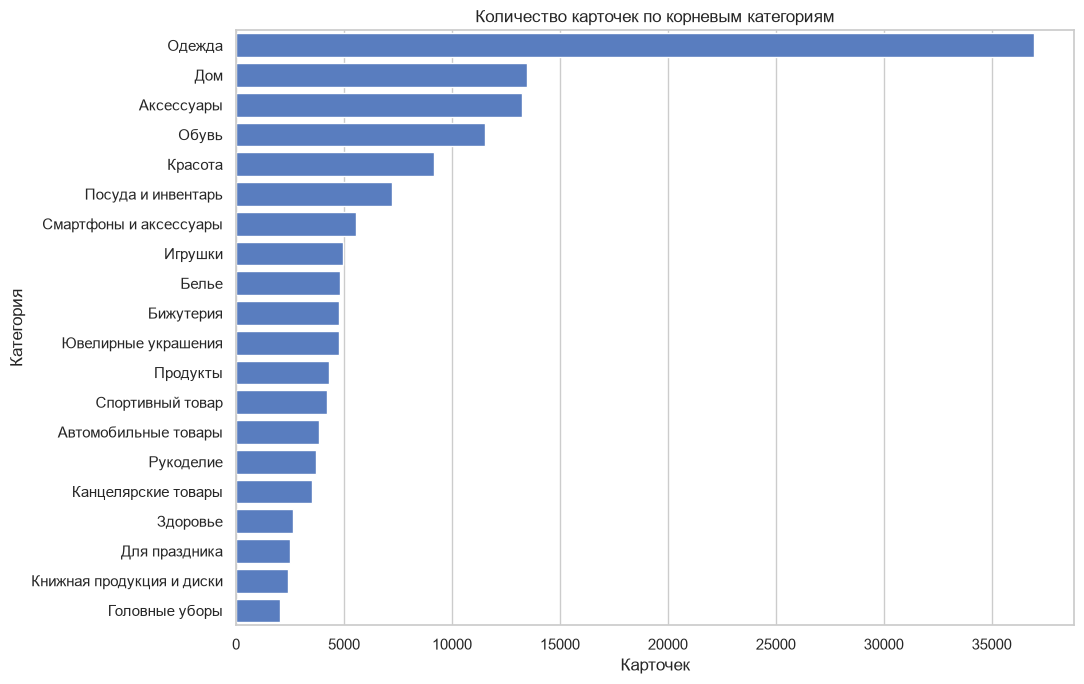

In [101]:
plot_data = root_counts.head(20).reset_index()
plt.figure(figsize=(11, 7))
sns.barplot(data=plot_data, x="cards", y="subj_root_name")
plt.title("Количество карточек по корневым категориям")
plt.xlabel("Карточек")
plt.ylabel("Категория")
plt.tight_layout()
plt.show()


**Категории.** В выгрузке 64 заполненные корневые категории и 3 233 заполненные предметные категории. Пустая строка даёт ещё одно значение в каждом из этих полей. У восьми карточек корневая категория не указана. Наиболее крупная категория — одежда: 36 965 карточек. В обуви 11 524 карточки. Для 820 предметных категорий представлено всего по одной-две карточки, поэтому единая оценка по всему каталогу скрывала бы сильную неоднородность данных.

In [102]:
# Слова и символы позволяют оценить длину; лимит модели позже проверим токенизатором.
lengths = pd.DataFrame(index=df_raw.index)
for col in ["imt_name", "description"]:
    text = df_raw[col].fillna("").astype(str)
    lengths[col + "_chars"] = text.str.len()
    lengths[col + "_words"] = text.str.split().str.len()
display(lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)


,count,mean,std,min,50%,90%,95%,99%,max
imt_name_chars,200000.000,32.866,23.961,0.000,31.000,65.000,80.000,97.000,122.000
imt_name_words,200000.000,4.802,3.643,0.000,4.000,10.000,12.000,15.000,31.000
description_chars,200000.000,372.371,474.557,0.000,227.000,934.000,1082.000,2067.000,5000.000
description_words,200000.000,50.385,64.586,0.000,31.000,125.000,152.000,289.000,754.000


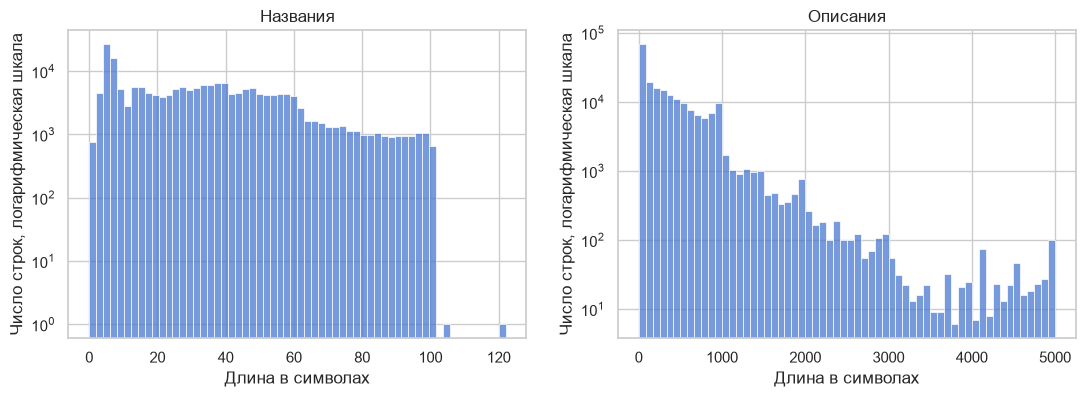

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["imt_name_chars", "description_chars"]):
    # Логарифмическая шкала числа наблюдений сохраняет видимость редких длинных текстов.
    sns.histplot(data=lengths, x=col, bins=60, ax=ax)
    ax.set_yscale("log")
    ax.set_title("Названия" if col == "imt_name_chars" else "Описания")
    ax.set_xlabel("Длина в символах")
    ax.set_ylabel("Число строк, логарифмическая шкала")
plt.show()


In [104]:
display(df_raw.loc[lengths["description_chars"].nlargest(5).index,
                   ["imt_id", "imt_name", "description"]])


,imt_id,imt_name,description
39185,10035242,"Платье женское ""Gina"" большие размеры",Милые наши покупательницы! Мы от души благодарим Вас за долгие годы верности нашему бренду! И с удовольствием дарим ...
39186,10035243,"Платье женское ""Gwen"", большие размеры",Милые наши покупательницы! Мы от души благодарим Вас за долгие годы верности нашему бренду! И с удовольствием дарим ...
39939,10035872,Джинсы женские большие размеры высокая посадка,"Джинсы ""Lesley"" - великолепная базовая модель для вашего гардероба. Универсальная, подойдет и на каждый день, и на п..."
39940,10035873,"Джинсы женские ""Camilla"", большие размеры, высокая посадка","Джинсы ""Camilla"" - отличный выбор на каждый день. По фигуре, слегка заужены к низу, ремень в комплекте. Хорошая базо..."
39942,10035875,"Джинсы женские ""Josephine"", большие размеры,высокая посадка","Джинсы ""Josephine"" - великолепный выбор на каждый день и на праздник. Прямой крой, комфортная посадка, ремень в комп..."


**Длины текстов.** Медиана названия — 31 символ и четыре слова; медиана описания — 227 символов и 31 слово. У 99% строк описание не длиннее 2 067 символов, но максимум достигает 5 000 символов и 754 слов. Поэтому название удобно поставить в начало `product_text`, а описание использовать как источник назначения и характеристик.

Количество слов не равно количеству токенов модели. Решение о допустимой обрезке принимается ниже по токенизатору E5, отдельно для подготовленного каталога оценки. Логарифмическая шкала частот на графике позволяет видеть редкие длинные тексты без их удаления.


In [105]:
# Просмотр случайных карточек: HTML, реклама, артикулы, повторяющиеся описания.
sample_cards = df_raw.sample(min(25, len(df_raw)), random_state=SEED)
with pd.option_context("display.max_colwidth", 1500):
    display(sample_cards[["imt_id", "imt_name", "subj_name", "description",
                          "brand_name", "nm_colors_names"]])
sample_cards.to_csv(ARTIFACTS_DIR / "eda_sample_25.csv", index=False)


,imt_id,imt_name,subj_name,description,brand_name,nm_colors_names
119737,10108023,Набор гель-блестки для тела с кисточкой,Глиттеры,"Lucky набор гель-блестки д тела/лица х3 шт + кисточка, цвета: синий, серебро, пурпур, на блистере.",LUKKY,"глубокий пурпурный, синий"
72272,10064796,Пирсинг для пупка серебро 925 проба,Ювелирный пирсинг,"Изделие выполнено из серебра 925 пробы; покрытие: родирование; средний вес: 0,35 гр; длина: 1,5 см; ширина: 1 мм; диаметр: 2 мм. Ювелирное украшение имеет пробу, что подтверждает его подлинность. Приобретая данное изделие - вы получаете готовое решение для подарка. Значение веса в характеристиках является примерным и может незначительно отличаться от фактического.\n\nПирсинг Rich Line станет отличным подарком на любой праздник человеку, который носит такие украшения или любит экспериментировать со стилем. Размер пирсинга не надо подбирать, он универсален, поэтому вы всегда угадаете с подарком. У нас есть как крупные сережки для пирсинга с камнями, так и изящные серебряные изделия. Пирсинг изготовлен из серебра 925 пробы или серебра с позолотой, поэтому он не вызывает аллергии и не раздражает прокол. Моделей множество: пирсинг для брови, пирсинг для губ, пирсинг для носа, пирсинг для пупка, пирсинг для ушей. Есть модели как без замка, так и с винтовой застежкой.\n\nПодарок маме, подарок девушке, подарок любимой женщине, подарок бабушке, подарок подруге, подарок на день всех влюбленных (14 февраля), подарок для мамы, подарок для девушки, подарок на 8 марта, подарок на день рождения, подарок на др, подарок на день матери, подарок на годовщину, подарок на новый год, подарок коллеге, подарок корпоративный, красивый подарок, серебряный пирсинг, пирсинг из серебра, пирсинг под золото, пирсинг с позолотой, пирсинг женский, пирсинг женский серебро, пирсинг 925 серебро, дизайнерски...",RICH LINE,серебристый
158154,10147294,Чехол на Samsung Galaxy M21 / M30s / M31,Чехлы для телефонов,"Противоударный чехол отлично защищает смартфон при падении. Удобная подставка позволит комфортно просматривать видео. Бортик чехла выступает над дисплеем телефона, что позволит спокойно класть телефон вниз экраном.",Kupicase,оранжевый
65426,10058577,Набор стикеров Аниме Naruto (Наруто),Стикеры,"В набор входит 63 стикера. Стикеры можно клеить куда угодно, как на любую технику, так и на школьные принадлежности.",FANDOM,белый
30074,10027164,Контактные линзы Pure Vision 2 (6 линз) R 8.6 D -6.00,Контактные линзы,"В этих одномесячных линзах идеально сочетаются высокая четкость зрения и гарантированный комфорт. Они идеально корригируют зрение с утра до самого вечера: даже в темное время Вы сможете ясно видеть все вокруг, а изображение будет четким и контрастным, избавленным от ореолов и бликов. Контактные линзы PureVision 2 HD необычайно тонки - всего 0,07 мм, а их края имеют немного закругленную форму - за счет этого линзы совершенно не чувствуются на глазах и незаметны даже для Вас самих. Кислородопроницаемость PureVision 2 HD довольно высока - на протяжении 24 часов они обеспечивают свободный доступ кислорода к поверхности глаза, поэтому носить их чрезвычайно комфортно и удобно.",Bausch+Lomb,
23677,10021271,"Головка 1/2"" DR со вставкой TORX T70 длиной 100мм (AT-BS-31)",Головки торцевые,"Инструменты соответствуют высоким стандартам качества, поэтому подойдут как для использования на бытовом уровне, так и для применения в профессиональной сфере.\nИнструменты изготовлены из высококачественной хром-ванадиевой стали. Металлические части изготовлены методом горячей ковки, что придаёт им высокую прочность и долговечность. Финишное прочное хромированное покрытие защищает Инструмент от воздействия коррозии, делает его более износостойким и легко очищается от загрязнений. Финишная обработка двух типов (частичная полировка) головок придаёт им отличный внешний вид.",Airline,
134858,10126692,"Сумка для ноутбука 13.3"" с косметичкой",Сумки для ноутбуков,"В комплекте: Сумка для ноутбука + косметичка.\n\nРазмер 13.3 дюйма \nвнешний размер 35*26*3

In [106]:
has_html = df_raw["description"].fillna("").str.contains(r"<[^>]+>", regex=True)
print(f"Описания с HTML: {has_html.mean():.2%}")
nonempty_descriptions = df_raw.loc[~empty_text(df_raw["description"]), "description"]
display(nonempty_descriptions.value_counts().head(10).to_frame("Частота описания"))
print("Уникальных непустых брендов:",
      df_raw.loc[~empty_text(df_raw["brand_name"]), "brand_name"].nunique())

print("Уникальных непустых цветов:",
      df_raw.loc[~empty_text(df_raw["nm_colors_names"]), "nm_colors_names"].nunique())


Описания с HTML: 0.01%


,Частота описания
description,
"Коврики изготовлены именно для Вашего автомобиля , полностью повторяют форму пола, на 100% защищая его от грязи. Не промокают. Европейский материалы. Максимальный комфорт и уют. Не промокают. Гарантия 2 года. Текстильные коврики не скользят по полу за счет штатных оригинальных креплений. Есть коврики на все модели.",218
Проект Автоистория - это модели автомобилей в масштабе по демократичным ценам. Продукция проходит обязательную сертификацию и соответствует ГОСТ 25779-90. Товарные знаки используются с разрешения правообладателей.,181
Гарантийный срок товара 30 дней.,166
"Не спешите писать негативный отзыв при следующих ситуациях, независящих от нас: 1. Доставка задержалась или качество обслуживания в пункте выдачи не оправдало Ваших ожиданий. В данном случае напишите в техподдержку для оперативного решения. 2. Товар пришел поврежденным. Вы вправе отказаться от покупки и/или оформить возврат по браку. Товар спишут и утилизируют за наши средства, несмотря на вину доставщика/курьера, а Вам вернут денежные средства. 3. Пришел абсолютно другой товар. Пересортица товаров может происходить на складе. К сожалению, мы никак не можем повлиять на работу отдельных сотрудников марткеплейса, как бы этого не хотели. В данном случае необходимо оформить возврат, написать в техподдержку. С уважением, Ваш kari.",152
"Полотенцесушитель водяной от производителя Терминус представляет собой оригинальную модификацию устройства форм-фактора ""Лесенка"". Конструкция устройства позволит разместить на нём большое количество вещей для просушки и придаст помещению элегантности, дополнив его стильным аксессуаром.",150
"Защищает от воздействия окружающей среды и одновременно является аксессуаром. Маска многоразовая, можно стирать. Не является медицинским изделием, ее рекомендуется носить поверх медицинской маски. Материал: полиэстер, хлопок.",148
"Очки для зрения женские являются неотъемлемой частью образа современной женщины. Наш магазин предлагает Вам легкие и стильные очки, которые помогут не только корректировать зрение, но и стать настоящим аксессуаром модного образа. Особенности данного товара включают в себя дизайн, который отличается изящностью и элегантностью. Легкая пластиковая оправа изготовлена из прочного материала, что обеспечивает комфортное ношение на протяжении всего дня. Очки корригирующие обеспечивают ясное и четкое видение, благодаря чему Вы сможете наслаждаться чтением или любыми другими ежедневными задачами. Мы предлагаем широкий ассортимент моделей и цветов, чтобы Вы смогли подобрать очки, которые будут соответствовать Вашему индивидуальному стилю и предпочтениям. Заказав очки для зрения в нашем интернет-магазине, Вы получите высококачественный продукт, который поможет Вам исправить зрение и стать еще красивее.",145
"Матовый силиконовый чехол TELEPRO Matte Silicone отличное дополнение к Вашему смартфону. Приятная на ощупь, нескользящая поверхность практична в использовании, она более устойчива к царапинам и потертостям и на ней не видны отпечатки пальцев. Подходит для беспроводной зарядки.",140
"Водяной полотенцесушитель Grota много лет пользуется застуженной популярностью. Он характеризуется исключительной надёжностью, которая гарантирует многолетнюю эксплуатацию полотенцесушителя, в течении которой у Вас не возникнет с ним малейших проблем. Радиатор сочетает исключительно высокие эксплуатационные и эстетические характеристики, что превращает его в идеальное дизайнерское дополнение ванной или другой комнаты.",140


Уникальных непустых брендов: 13318
Уникальных непустых цветов: 9646


In [107]:
# точное вхождение хотя бы одного цвета в названии
def color_in_title(row):
    colors = [part.strip().casefold() for part in str(row["nm_colors_names"]).split(",")]
    title = str(row["imt_name"]).casefold()
    return any(color and re.search(r"(?<!\w)" + re.escape(color) + r"(?!\w)", title)
               for color in colors)

with_color = df_raw.loc[~empty_text(df_raw["nm_colors_names"])]
if len(with_color):
    print(f"Цвет явно присутствует в названии: {with_color.apply(color_in_title, axis=1).mean():.2%}")


Цвет явно присутствует в названии: 2.65%


In [108]:
# Выведем топ 20 самых популярных и самых редких цветов в каталоге, чтобы оценить их разнообразие и частоту.
color_counts = df_raw["nm_colors_names"].dropna().str.split(",").explode().str.strip().value_counts()
display(color_counts.head(20).to_frame("Частота"))

colors_rare = color_counts[color_counts <= 5]
display(colors_rare.to_frame("Частота редких цветов").sort_values("Частота редких цветов", ascending=True).head(20))

,Частота
nm_colors_names,
,34226
черный,31425
белый,27127
синий,12713
красный,10658
серый,10416
розовый,10328
серебристый,9461
бежевый,8664


,Частота редких цветов
nm_colors_names,
белый бриллиант,1
синий неон,1
сандаловое дерево,1
орех,1
зеленое мох,1
дуб молочный,1
кобальт,1
глубокий пурпурно-розовый,1
серый металлик,1


**Качество текста, бренд и цвет.** Для просмотра выбраны 25 строк с фиксированным seed. В них встречаются полезные числовые характеристики и обозначения моделей, например размер сумки 13,3 дюйма и совместимость чехлов с моделями телефонов, а также рекламные формулировки. Поэтому очистка убирает HTML, управляющие символы и лишние пробелы, но сохраняет числа, дефисы и обозначения моделей. Массовое удаление «рекламных» слов без отдельной проверки не применяется, чтобы не потерять полезные признаки.

У разных товаров встречаются одинаковые описания. Пока они сохранены: без дополнительной проверки их удаление может привести к потере полезных характеристик.

HTML найден примерно в 0,01% описаний. Непустых брендов — 13 318. Хотя бы один цвет из отдельного поля буквально встречается в названии у 2,65% строк с заполненным цветом. Проверка не учитывает склонения, поэтому это оценка точных совпадений, а не полного смыслового дублирования.

Отдельные поля `brand_name` и `nm_colors_names` не добавляются в `product_text`. Исключение отдельного поля бренда соответствует ответу наставника на Q&A (12:04–15:02). Упоминания бренда и цвета в названии или описании сохраняются. После дедупликации в атрибутах остаётся цвет выбранного варианта карточки.


**Цвета товаров.** В поле `nm_colors_names` обнаружено 9 646 уникальных непустых значений. Это число включает сочетания цветов, например «черный, белый», поэтому не равно количеству отдельных цветов.

После разделения значений по запятой чаще всего встречаются чёрный — 31 425 раз, белый — 27 127 и синий — 12 713. Частоты рассчитаны по исходным строкам, до объединения вариантов карточек.

Среди редких значений встречаются уточнённые оттенки и названия отделки: «синий неон», «мокрый асфальт», «дуб молочный». Они не обязательно ошибочны, поэтому удалять их только из-за низкой частоты не следует.

Пустая строка встречается 34 226 раз и попала в таблицу частот, поскольку `dropna()` не удаляет пустые строки. Её нужно исключить из рейтинга цветов и учитывать как пропуск. В текущем поиске отдельное поле цвета не включается в `product_text`.

В дальнейшем можно унифицировать написание цветов, разделить составные значения и сопоставить редкие оттенки с базовыми цветами, сохранив исходные названия. Это позволит точнее учитывать цвет в запросах. Пользу такой обработки нужно проверить отдельно: слишком грубое объединение оттенков может ухудшить поиск.

In [109]:
# Обзор разметки train, без обращения к test.
print("Пар запрос — товар:", len(queries_train))
print("Уникальных запросов:", queries_train["query_id"].nunique())
print("Размеченных товаров:", queries_train["item_id"].nunique())
display(queries_train.groupby("query_id")["item_id"].nunique().describe())
display(queries_train["relevance"].value_counts().sort_index().to_frame("Число пар"))


Пар запрос — товар: 11453
Уникальных запросов: 700
Размеченных товаров: 2285


count   700.000
mean     16.361
std       5.424
min       1.000
25%      14.000
50%      16.000
75%      19.000
max      31.000
Name: item_id, dtype: float64

,Число пар
relevance,
1,9652
2,1101
3,700


In [110]:
# Порог 2 предложен в шаблоне: считаем положительными оценки 2–3
# Оценку 1 не засчитываем: слабого соответствия недостаточно для хорошего результата поиска.
# Для NDCG сохраняем исходные оценки 0–3.
RELEVANCE_THRESHOLD = 2


In [111]:
positive_counts = queries_train.assign(
    relevant=queries_train["relevance"].ge(RELEVANCE_THRESHOLD)
).groupby("query_id")["relevant"].sum()
print("Запросов без релевантных товаров:", positive_counts.eq(0).sum())
display(queries_train[["query_id", "query_text"]].drop_duplicates().sample(
    min(15, queries_train["query_id"].nunique()), random_state=SEED
))


Запросов без релевантных товаров: 0


,query_id,query_text
2484,SYN_000210,топы cop copine
8139,SYN_000714,худи mego as
6376,SYN_000561,бриджи зуавы
2446,SYN_000206,кожаные мокасины
5214,SYN_000450,кожаные сабо с открытым мысом
3373,SYN_000286,классические джинсовые джинсы
3746,SYN_000318,шубы натуральные на пуговицах
4678,SYN_000401,тапочки asd
4852,SYN_000414,тапочки t taccardi
5737,SYN_000505,кигуруми londe


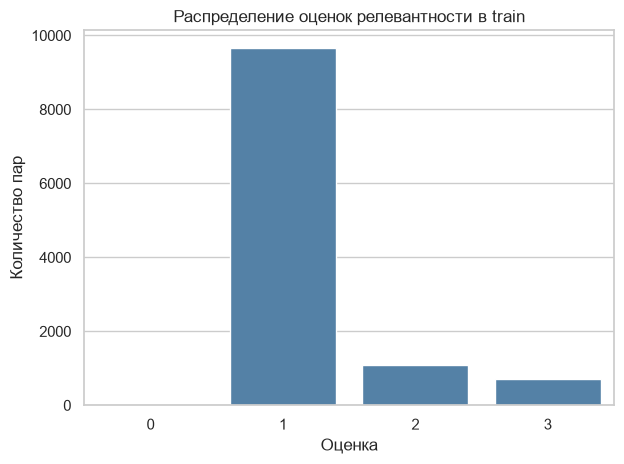

In [112]:
sns.countplot(data=queries_train, x="relevance", order=[0, 1, 2, 3], color="steelblue")
plt.title("Распределение оценок релевантности в train")
plt.xlabel("Оценка")
plt.ylabel("Количество пар")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "relevance.png", dpi=140)
plt.show()


**Разметка и порог релевантности.** Train содержит 700 запросов и 2 285 разных оценённых товаров. На запрос приходится в среднем 16,36 оценённых товаров, медиана — 16, диапазон — от одного до 31. Оценок 1 — 9 652, оценок 2 — 1 101, оценок 3 — 700; оценка 0 в train не встречается. Однако неразмеченные товары при расчёте метрик получают 0 по протоколу задания.

Для бинарных метрик мы выбрали порог 2: оценки 2 и 3 считаем достаточным соответствием запросу, а оценку 1 — слабым. NDCG учитывает все оценки по шкале 0–3 с весами `2^relevance − 1`. При выбранном пороге у каждого запроса в train остаётся хотя бы один релевантный товар.

Среди примеров есть запросы по типу, материалу, фасону и бренду: «кожаные мокасины», «прямые жакеты», «пальто crockid». Это задача query-to-item. Запросы синтетические, поэтому полученные метрики нельзя напрямую переносить на реальные пользовательские логи.


---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [113]:
# 25% групп запросов оставляем для сравнения методов, 75% — для обучения.
# 175 запросов достаточно для первого сравнения; 525 остаются для обучения.
VALIDATION_SIZE = 0.25

# Группируем одинаковые запросы с разным регистром и пробелами.
queries_train["query_group"] = normalize_queries(queries_train["query_text"])
query_groups = queries_train["query_group"].drop_duplicates().sort_values()
fit_groups, valid_groups = train_test_split(
    query_groups, test_size=VALIDATION_SIZE, random_state=SEED
)
train_fit = queries_train.loc[queries_train["query_group"].isin(fit_groups)].copy()
validation = queries_train.loc[queries_train["query_group"].isin(valid_groups)].copy()


In [114]:
print("Запросов train:", train_fit["query_id"].nunique())
print("Запросов validation:", validation["query_id"].nunique())
print("Общих текстов:", len(set(train_fit["query_group"]) & set(validation["query_group"])))


Запросов train: 525
Запросов validation: 175
Общих текстов: 0


**Разделение данных.** Из 700 запросов выделено 525 для обучающей части и 175 для validation. Разбиение выполнено по нормализованному тексту: регистр и повторные пробелы не должны позволить одному запросу оказаться в обеих частях. Общих нормализованных текстов нет; нескольких разных текстов у одного `query_id` также не обнаружено.

Доля validation 25% выбрана как начальный компромисс: остаются 175 запросов для сравнения методов и 525 для последующего обучения. На второй неделе E5 не дообучается; `train_fit` используется для выбора домена и ручных примеров. TF-IDF обучается на доступных текстах каталога, а не на ответах validation. Оценки финального test остаются отложенными; его ID и тексты используются только для проверки пересечения с train.


In [115]:
# Убираем HTML и лишние пробелы, но сохраняем числа, размеры, дефисы и названия моделей.
def clean_text(value):
    if pd.isna(value):
        return ""
    text = html.unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\x00-\x1f\x7f]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


In [116]:
products = df_raw.drop_duplicates().copy()
for col in ["imt_name", "subj_name", "subj_root_name", "description",
            "brand_name", "nm_colors_names"]:
    products[col] = products[col].map(clean_text)

# Проверяем, встречаются ли разные корневые категории у одной карточки.
print("Карточек с конфликтом корневых категорий:",
      products.groupby("imt_id")["subj_root_name"].nunique().gt(1).sum())


Карточек с конфликтом корневых категорий: 0


In [117]:
# Фильтруем дубликаты карточек, оставляя одну строку на imt_id. Сначала непустое название, затем длинное описание, при равенстве — меньший nm_id.
products["has_name"] = products["imt_name"].ne("")
products["description_length"] = products["description"].str.len()
products = products.sort_values(
    ["imt_id", "has_name", "description_length", "nm_id"],
    ascending=[True, False, False, True], kind="stable",
).drop_duplicates("imt_id").copy()


In [118]:
# Выбор домена опирается только на обучающую часть разметки.
fit_categories = train_fit.loc[train_fit["relevance"].ge(RELEVANCE_THRESHOLD)].merge(
    products[["imt_id", "subj_root_name"]], left_on="item_id", right_on="imt_id",
    how="left", validate="many_to_one",
)


In [119]:
category_support = fit_categories.groupby("subj_root_name")["query_id"].nunique()
category_support = category_support.drop(index="", errors="ignore").sort_values(ascending=False)
display(category_support.to_frame("Запросов с релевантными товарами"))


,Запросов с релевантными товарами
subj_root_name,
Одежда,379
Обувь,146


In [120]:
# В задании рекомендован MVP на 1–3 категориях. 
# Выбираем по числу уникальных train-запросов с оценками 2–3, чтобы хватало разметки.
selected_roots = category_support.head(3).index.tolist()
print("Категории MVP:", selected_roots)


Категории MVP: ['Одежда', 'Обувь']


**Выбор домена.** Положительные пары в `train_fit` относятся к двум корневым категориям: 379 запросов связаны с одеждой и 146 — с обувью. Поэтому фактически выбраны **«Одежда» и «Обувь»**, хотя код допускает до трёх категорий. Это соответствует ответу наставника на Q&A (09:15–09:45): MVP ограничивается категориями с проверенной разметкой. Данные test для выбора не использовались.


In [121]:
# Сохраняем ID домена до отсева пустых карточек, чтобы показать потери в оценке.
domain_ids = set(products.loc[products["subj_root_name"].isin(selected_roots), "imt_id"])
products = products.loc[products["imt_id"].isin(domain_ids)].copy()
empty_cards = products["imt_name"].eq("") & products["description"].eq("")
print("Удалено карточек без названия и описания:", empty_cards.sum())
products = products.loc[~empty_cards].copy()


Удалено карточек без названия и описания: 113


In [122]:
# Единый текст для обоих методов: название, категория и описание.
# Сохраняем прежние разделители, чтобы не менять входные тексты поиска.
products["product_text"] = (
    (products["imt_name"] + ". " + products["subj_name"]).str.strip(". ")
    + ". " + products["description"]
).str.strip(". ")
products = products.sort_values("imt_id").reset_index(drop=True)
products.to_parquet(ARTIFACTS_DIR / "products_prepared.parquet", index=False)
display(products[["imt_id", "imt_name", "subj_name", "description", "product_text"]].head())


,imt_id,imt_name,subj_name,description,product_text
0,100032,Платье,Платья,,Платье. Платья
1,100033,Куртка,Куртки,,Куртка. Куртки
2,100035,Сандалии,Сандалии,,Сандалии. Сандалии
3,100037,Ботинки,Ботинки,,Ботинки. Ботинки
4,100083,Сандалии,Сандалии,,Сандалии. Сандалии


**Дедупликация и текст карточки.** При выборе строки для одного `imt_id` сначала сохраняется вариант с непустым названием, затем с наиболее длинным описанием, а при равенстве — с меньшим `nm_id`. Это простое воспроизводимое правило: название задаёт тип товара, длина описания приближённо отражает объём доступных характеристик. 

Удалены 113 карточек без названия и описания. Карточки с названием, но без описания, сохранены.

Для поиска используется текст из названия, предметной категории и описания. Описание сохраняет сведения о назначении и свойствах товара, которых может не быть в названии. Поля разделены точкой; пустые поля не превращаются в строки `nan` или `None`.


### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

In [123]:
# Служебный файл используется только как список ID, тексты остаются нашими.
assessed_ids = set(assessed_pool["imt_id"])
catalog = products.loc[products["imt_id"].isin(assessed_ids)].reset_index(drop=True)
catalog.to_parquet(ARTIFACTS_DIR / "catalog_eval.parquet", index=False)
print("Карточек в полном каталоге выбранных категорий:", len(products))
print("Карточек в каталоге оценки:", len(catalog))
print("ID из пула, отсутствующих в raw:", len(assessed_ids - set(df_raw["imt_id"])))


Карточек в полном каталоге выбранных категорий: 48376
Карточек в каталоге оценки: 4256
ID из пула, отсутствующих в raw: 0


In [124]:
# Выбираем запросы, у которых есть хотя бы один размеченный товар
# из выбранных категорий. domain_ids содержит ID карточек этих категорий.
# Здесь учитываем любую оценку: запрос не обязан иметь релевантный товар.
selected_query_ids = validation.loc[
    validation["item_id"].isin(domain_ids), "query_id"
].unique()

# Сохраняем все пары «запрос — товар» для выбранных запросов.
# Товары вне каталога пока оставляем, чтобы проверить возможные потери.
selected_pairs = validation.loc[
    validation["query_id"].isin(selected_query_ids)
].copy()

print(
    "Запросов до / после выбора категорий:",
    validation["query_id"].nunique(), "/",
    len(selected_query_ids),
)

# Для каждой пары отмечаем:
# 1. Есть ли товар в каталоге оценки.
# 2. Считается ли он релевантным запросу при выбранном пороге.
in_catalog = selected_pairs["item_id"].isin(catalog["imt_id"])
is_relevant = selected_pairs["relevance"].ge(RELEVANCE_THRESHOLD)

# Проверяем, сколько релевантных пар потеряется при ограничении каталога.
# Такие товары поиск не сможет вернуть, потому что их нет среди кандидатов.
print(
    "Релевантных пар вне каталога оценки:",
    (is_relevant & ~in_catalog).sum(),
)

# Оставляем разметку только для доступных товаров.
# Сохраняем все их оценки, включая 1, а не только релевантные пары.
# Эта таблица нужна для расчёта метрик.
valid_qrels = selected_pairs.loc[in_catalog].copy()

# Формируем список запросов для проверки поиска.
# Берём его до исключения товаров вне каталога, чтобы не потерять
# запросы, у которых после фильтрации не осталось подходящих товаров.
valid_queries = selected_pairs[
    ["query_id", "query_text"]
].drop_duplicates()

# Находим запросы, у которых в каталоге есть хотя бы один товар
# с оценкой не ниже выбранного порога.
queries_with_relevant_items = set(
    valid_qrels.loc[
        valid_qrels["relevance"].ge(RELEVANCE_THRESHOLD), "query_id"
    ]
)

# Разность множеств показывает запросы без релевантных товаров в каталоге.
# Мы сообщаем их количество, но не исключаем их из оценки.
queries_without_relevant_items = (
    set(valid_queries["query_id"]) - queries_with_relevant_items
)

print(
    "Запросов без доступных релевантных товаров:",
    len(queries_without_relevant_items),
)

# Сохраняем запросы и разметку: ниже эти файлы записываются в MLflow
# вместе с результатами, чтобы зафиксировать данные для оценки.
valid_queries.to_csv(
    ARTIFACTS_DIR / "validation_queries.csv", index=False
)
valid_qrels.to_parquet(
    ARTIFACTS_DIR / "validation_qrels.parquet", index=False
)

Запросов до / после выбора категорий: 175 / 175
Релевантных пар вне каталога оценки: 0
Запросов без доступных релевантных товаров: 0


**Каталог для оценки.** Из 48 376 подготовленных карточек выделен общий пул оценки — 4 256 ID из `wb_products_dedup.parquet`. Все ID пула найдены в raw-каталоге. Тексты и признаки сформированы из raw, а служебный файл задаёт только множество кандидатов. 

После ограничения домена сохранены все 175 validation-запросов; положительных пар вне каталога оценки нет, запросов без доступного релевантного товара тоже нет. Таким образом, в этом запуске фильтрация не уменьшила число положительных validation-пар. Поиск каждого метода идёт по всем 4 256 карточкам, а не только по оценённым товарам конкретного запроса. Оба метода проверяются на одинаковых запросах, разметке и каталоге товаров.


### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:

In [125]:
# Общая сортировка для всех методов. При одинаковом score сохраняем порядок imt_id.
def top_items(frame, scores, top_k=10):
    if top_k < 1:
        raise ValueError("top_k должен быть положительным")
    order = np.argsort(-np.asarray(scores), kind="stable")[:top_k]
    result = frame.iloc[order][["imt_id", "imt_name", "subj_name"]].copy()
    result["score"] = np.asarray(scores)[order]
    return result.reset_index(drop=True)


Реализуйте лексический baseline на TF-IDF:

In [126]:
# TF-IDF обучается на каталоге: тексты товаров доступны до поступления запросов.
def build_lexical(frame):
    vectorizer = TfidfVectorizer(
        lowercase=True, analyzer="word", ngram_range=(1, 2),
        min_df=1, sublinear_tf=True, max_features=100_000, dtype=np.float32,
    )
    matrix = vectorizer.fit_transform(frame["product_text"])

    def score_query(query):
        vector = vectorizer.transform([clean_text(query)])
        return (matrix @ vector.T).toarray().ravel()

    return score_query, vectorizer, matrix


In [127]:
# Построение лексических оценок
lexical_scores, _, tfidf_matrix = build_lexical(catalog)


In [128]:
def search_lexical(query: str, top_k: int = 10) -> pd.DataFrame:
    return top_items(catalog, lexical_scores(query), top_k)


print("Размер TF-IDF матрицы:", tfidf_matrix.shape)


Размер TF-IDF матрицы: (4256, 100000)


**Лексический baseline.** TF-IDF выбран как простая воспроизводимая точка отсчёта. Униграммы и биграммы `(1, 2)` позволяют учитывать отдельные слова и сочетания вроде «зимние сапоги». Ограничение словаря в 100 000 признаков сдерживает размер матрицы; фактическая матрица имеет форму `(4256, 100000)`, то есть лимит достигнут

`min_df=1` сохраняет редкие слова, которые могут быть значимыми названиями и артикулами. `sublinear_tf=True` уменьшает влияние повторения одного слова в описании. Значения `float32` сокращают память матрицы. Запрос проходит ту же очистку, а векторизатор приводит регистр и нормализует векторы, поэтому скалярное произведение соответствует косинусному сходству. При равных оценках сохраняется порядок по `imt_id`, чтобы выдача была воспроизводимой.


Реализуйте семантический поиск:

In [129]:
# Мультиязычная модель для поиска: https://huggingface.co/intfloat/multilingual-e5-base
MODEL_NAME = "intfloat/multilingual-e5-base"
# Начальный размер партии для расчёта на GPU; отдельный подбор скорости не проводился.
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)


Устройство: cuda


In [130]:
# При первом запуске веса модели будут скачаны с Hugging Face.
# Правила E5: query: для запросов, passage: для товаров, нормализация векторов.
# Документация: https://huggingface.co/intfloat/multilingual-e5-base
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
model.max_seq_length = 512
MODEL_REVISION = getattr(model[0].auto_model.config, "_commit_hash", None) or "unknown"


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 30049.92it/s]


In [131]:
def encode_products(texts):
    return model.encode(
        ["passage: " + text for text in texts], batch_size=BATCH_SIZE,
        normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True,
    )


In [132]:
def encode_query(query):
    return model.encode(
        ["query: " + clean_text(query)], normalize_embeddings=True,
        show_progress_bar=False, convert_to_numpy=True,
    )[0]


In [133]:
## Вычисляем эмбеддинги товаров
product_embeddings = encode_products(catalog["product_text"].tolist())

Batches: 100%|██████████| 133/133 [00:02<00:00, 45.62it/s] 


In [134]:
def semantic_scores(query):
    # Преобразуем запрос в вектор.
    query_embedding = encode_query(query)

    # Сравниваем его с вектором каждого товара.
    # Векторы нормализованы, поэтому скалярное произведение равно косинусной близости: чем выше оценка, тем ближе тексты.
    scores = product_embeddings @ query_embedding
    return scores


def search_semantic(query: str, top_k: int = 10) -> pd.DataFrame:
    return top_items(catalog, semantic_scores(query), top_k)


print("Размер матрицы эмбеддингов:", product_embeddings.shape)


Размер матрицы эмбеддингов: (4256, 768)


In [135]:
# Проверяем реальную длину в токенах до обрезки, а не заменяем её числом слов.
token_lengths = []
for start in range(0, len(catalog), BATCH_SIZE):
    texts = ["passage: " + text for text in catalog["product_text"].iloc[start:start + BATCH_SIZE]]
    tokens = model.tokenizer(texts, truncation=False, padding=False)
    token_lengths.extend(len(ids) for ids in tokens["input_ids"])
token_lengths = pd.Series(token_lengths)
display(token_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print(f"Доля обрезаемых текстов: {token_lengths.gt(model.max_seq_length).mean():.2%}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


count   4256.000
mean     107.644
std      108.948
min        8.000
50%       78.000
90%      247.500
95%      304.000
99%      533.700
max     1135.000
dtype: float64

Доля обрезаемых текстов: 1.25%


**Семантическая модель.** Модель `intfloat/multilingual-e5-base` преобразует запросы и товары в векторы. К запросам добавляется префикс `query:`, к товарам — `passage:`. Поиск сравнивает запрос со всеми 4 256 товарами по косинусной близости и возвращает наиболее похожие.

В сохранённом запуске векторы рассчитаны на GPU партиями по 32 товара и сохранены вместе с ID. Это начальный размер партии, отдельный подбор скорости не проводился. При повторном запуске ячейки векторы рассчитываются заново.

Тексты ограничены 512 токенами; обрезка затрагивает 1,25% карточек. Название и категория стоят в начале, чтобы сохранить их при обрезке описания.


Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [136]:
# Первичная ручная проверка на запросах обучающей части.
manual_queries = train_fit.loc[train_fit["item_id"].isin(catalog["imt_id"]),
                               ["query_id", "query_text"]].drop_duplicates()
for row in manual_queries.sample(min(5, len(manual_queries)), random_state=SEED).itertuples():
    print("Запрос:", row.query_text)
    print("TF-IDF:")
    display(search_lexical(row.query_text, 5))
    print("Семантический поиск:")
    display(search_semantic(row.query_text, 5))

Запрос: шелковые топы
TF-IDF:


,imt_id,imt_name,subj_name,score
0,10016977,Топы,Топы,0.716
1,101146,Топ,Топы,0.542
2,10042858,Майка,Топы,0.471
3,10150664,Топ - CINTIA,Топы,0.455
4,10022566,Топ женский,Топы,0.384


Семантический поиск:


,imt_id,imt_name,subj_name,score
0,10031321,Топ шелковый бельевой под пиджак,Топы,0.881
1,10179763,Топ на тонких бретельках/шелковый (вискоза 100%),Топы,0.871
2,10103803,Топ женский,Топы,0.865
3,10016977,Топы,Топы,0.842
4,10010349,Топ,Топы,0.840


Запрос: приталенные хлопковые жакеты
TF-IDF:


...

,imt_id,imt_name,subj_name,score
0,10043424,Комбинезон защитный одноразовый,Комбинезоны,0.896
1,10016095,Комбинезон из однотонной ткани,Комбинезоны,0.863
2,10024554,Комбинезон,Комбинезоны,0.850
3,10013875,Комбинезон,Комбинезоны,0.850
4,10108993,Комбинезон,Комбинезоны,0.849


Запрос: кожаные сандалии
TF-IDF:


,imt_id,imt_name,subj_name,score
0,100464,Сандалии,Сандалии,0.377
1,10068273,Сандалии / Туфли / Босоножки,Сандалии,0.251
2,1003230,Сандалии,Туфли,0.244
3,10019008,Сандалии,Босоножки,0.243
4,10171853,Сандалии / Женские / Искусственная кожа,Сандалии,0.217


Семантический поиск:


,imt_id,imt_name,subj_name,score
0,10013140,Босоножки кожа Турция,Сандалии,0.881
1,10045302,Сандалии,Сандалии,0.864
2,10020938,Сандалии,Сандалии,0.860
3,10012463,Сандалии для мальчика кожаные м.01280/5С,Сандалии,0.859
4,10160889,Сандалии,Туфли,0.859


**Ручное сравнение выдачи.** Проверены пять запросов обучающей части, для каждого показан top-5 обоих методов. Для «комбинезоны защитный одноразовый» оба метода ставят на первое место карточку с таким названием: на точном совпадении TF-IDF уже решает задачу.

Для «шелковые топы» семантический поиск поднимает карточку «Топ шелковый бельевой под пиджак», а для «кожаные сандалии» — «Босоножки кожа Турция». Это иллюстрирует потенциальную пользу сопоставления характеристик и близких названий. На втором месте по запросу «шелковые топы» стоит «Топ на тонких бретельках/шелковый (вискоза 100%)»: сходство текста не гарантирует совпадения материала. Для «приталенные хлопковые жакеты» коротких названий в выдаче недостаточно, чтобы подтвердить оба атрибута: нужны полные карточки и оценки.


### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [137]:
# Оцениваем первые 5 и 10 результатов: K=5 — качество начала выдачи,
# K=10 — сколько релевантных товаров найдётся при просмотре более длинного списка.
# Одинаковые K для обоих методов обеспечивают сопоставимость метрик.
K_VALUES = (5, 10)

In [138]:
def query_metrics(ranked_ids, relevance_map, threshold=RELEVANCE_THRESHOLD):
    # Оценки товаров в порядке выдачи. Если оценки нет, используем 0.
    relevance = np.array([
        relevance_map.get(item_id, 0) for item_id in ranked_ids
    ])
    is_relevant = relevance >= threshold

    # Всего релевантных товаров по разметке для этого запроса.
    total_relevant = sum(
        score >= threshold for score in relevance_map.values()
    )

    # Лучший возможный порядок товаров: от высокой оценки к низкой.
    ideal_relevance = np.array(
        sorted(relevance_map.values(), reverse=True)
    )

    metrics = {}

    for k in K_VALUES:
        # Количество релевантных товаров среди первых k результатов.
        hits = is_relevant[:k].sum()

        metrics[f"precision_at_{k}"] = float(hits / k)
        metrics[f"recall_at_{k}"] = (
            float(hits / total_relevant) if total_relevant else 0.0
        )
        metrics[f"hit_rate_at_{k}"] = float(hits > 0)

        # NDCG учитывает и оценку товара, и его позицию в выдаче.
        # Чем дальше позиция, тем меньше её вклад.
        top_relevance = relevance[:k]
        discounts = np.log2(np.arange(len(top_relevance)) + 2)
        dcg = np.sum((2.0 ** top_relevance - 1) / discounts)

        # Сравниваем результат с лучшим возможным ранжированием.
        ideal_top = ideal_relevance[:k]
        ideal_discounts = np.log2(np.arange(len(ideal_top)) + 2)
        ideal_dcg = np.sum((2.0 ** ideal_top - 1) / ideal_discounts)

        metrics[f"ndcg_at_{k}"] = (
            float(dcg / ideal_dcg) if ideal_dcg else 0.0
        )

    # Обратная позиция первого релевантного товара во всей выдаче.
    # Усреднение этого значения по запросам даст MRR.
    relevant_positions = np.flatnonzero(is_relevant)
    metrics["mrr"] = (
        1.0 / (relevant_positions[0] + 1)
        if relevant_positions.size > 0 else 0.0
    )

    return metrics

In [139]:
def evaluate(score_function, frame, query_list, qrels):
    # Для каждого запроса создаём словарь:
    # ID товара → оценка релевантности.
    relevance_maps = {}
    for query_id, group in qrels.groupby("query_id"):
        relevance_maps[query_id] = dict(
            zip(group["item_id"], group["relevance"])
        )

    results = []

    for query in query_list.itertuples(index=False):
        # Получаем оценки сходства запроса со всеми товарами.
        # Порядок оценок должен соответствовать строкам frame.
        start = perf_counter()
        scores = score_function(query.query_text)

        # Сортируем товары от наиболее подходящего к наименее подходящему.
        # При одинаковых оценках сохраняем исходный порядок.
        order = np.argsort(-scores, kind="stable")

        # Измеряем время расчёта оценок и сортировки в миллисекундах.
        # Расчёт метрик в это время не входит.
        latency_ms = (perf_counter() - start) * 1000

        # Получаем ID товаров в порядке выдачи.
        ranked_ids = frame["imt_id"].iloc[order].tolist()

        # Берём разметку запроса и рассчитываем его метрики.
        relevance_map = relevance_maps.get(query.query_id, {})
        metrics = query_metrics(ranked_ids, relevance_map)

        # Сохраняем результат одного запроса.
        result = {
            "query_id": query.query_id,
            "query_text": query.query_text,
            "latency_ms": latency_ms,
        }
        result.update(metrics)
        results.append(result)

    # Подробная таблица: одна строка на запрос.
    details = pd.DataFrame(results)

    # Итог: среднее каждой метрики и времени поиска по всем запросам.
    metric_columns = details.drop(columns=["query_id", "query_text"])
    summary = metric_columns.mean().to_dict()

    return summary, details

**Правила расчёта метрик.** Используются K = 5 и 10: первые пять позиций характеризуют начало выдачи, первые десять — более широкий результат поиска. Эти значения также согласуются с `check_mlflow.py`. Порог бинаризации равен 2, а NDCG считается по исходным оценкам 0–3. MRR вычисляется по полному ранжированию каталога, без усечения на десятой позиции.

Метрики сначала считаются для каждого запроса, затем усредняются с одинаковым весом запросов. Неразмеченный товар получает оценку 0. Recall и идеальное ранжирование для NDCG строятся по разметке общего каталога оценки. Если у запроса нет релевантных товаров или положительного IDCG, соответствующая метрика принимается равной нулю; в текущем validation нет запросов без релевантных товаров.


In [140]:
# Считаем оценки для всех товаров в каталоге, чтобы ускорить расчёт метрик.
full_scores, _, _ = build_lexical(products)
pool_mask = products["imt_id"].isin(catalog["imt_id"]).to_numpy()


In [141]:
def restricted_full_scores(query):
    return full_scores(query)[pool_mask]


In [142]:
comparison_queries = valid_queries.sample(min(100, len(valid_queries)), random_state=SEED)
full_summary, _ = evaluate(full_scores, products, comparison_queries, valid_qrels)
pool_summary, _ = evaluate(restricted_full_scores, catalog, comparison_queries, valid_qrels)
display(pd.DataFrame([full_summary, pool_summary], index=["Полный каталог", "Пул оценки"]))


,latency_ms,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr
Полный каталог,2.488,0.018,0.061,0.090,0.081,0.009,0.061,0.090,0.081,0.058
Пул оценки,2.371,0.058,0.150,0.220,0.350,0.070,0.316,0.440,0.436,0.179


In [143]:
example = comparison_queries.iloc[0]
example_relevance = valid_qrels.loc[valid_qrels["query_id"].eq(example["query_id"])].set_index("item_id")["relevance"]
example_top = top_items(products, full_scores(example["query_text"]), 10)
example_top["есть_разметка"] = example_top["imt_id"].isin(example_relevance.index)
example_top["relevance"] = example_top["imt_id"].map(example_relevance)
print("Запрос:", example["query_text"])
display(example_top)
print("NaN означает отсутствие оценки. Такие товары при расчёте метрик получают 0.")


Запрос: блузки rita pfeffinger


,imt_id,imt_name,subj_name,score,есть_разметка,relevance
0,10170287,"Легинсы,черный,s",Леггинсы,0.314,False,NaN
1,10170288,"Пуловер,бежевый,52",Пуловеры,0.254,False,NaN
2,10170273,"Блуза,розовый,56",Блузки,0.252,False,NaN
3,10145702,"Блуза,розовый,54",Блузки,0.239,False,NaN
4,10170279,"Блузка женская, кофта женская",Блузки,0.234,False,NaN
5,10145740,"Пуловер,серебристо-серый,46",Пуловеры,0.233,False,NaN
6,10170276,"Блузка женская, кофта женская",Блузки,0.228,False,NaN
7,10170278,"Блузка женская, кофта женская",Блузки,0.228,False,NaN
8,10145732,"Брюки,черный,56",Брюки,0.222,False,NaN
9,10100454,Платье,Блузки,0.214,False,NaN


NaN означает отсутствие оценки. Такие товары при расчёте метрик получают 0.


**Влияние пула оценки.** На одних и тех же 100 validation-запросах NDCG@10 лексического поиска составляет 0,081 по полному отфильтрованному каталогу и 0,436 по пулу оценки. Recall@10 меняется с 0,061 до 0,316. В этом опыте используется один TF-IDF, обученный на полном каталоге, поэтому сравнивается именно состав кандидатов.

Для запроса «блузки rita pfeffinger» все десять товаров полной выдачи отсутствуют в разметке этого запроса. Это не означает, что все они подходят: на первых позициях есть леггинсы и пуловер. Но оно показывает, что по имеющейся разметке нельзя надёжно судить обо всём каталоге.

Рост метрик после ограничения кандидатов не является улучшением модели. Это изменение условий оценки. Поэтому основные методы далее сравниваются на одном пуле из 4 256 карточек. Значения этого опыта нельзя напрямую смешивать с основной таблицей: здесь 100 запросов и TF-IDF полного каталога, а в основном сравнении — 175 запросов и TF-IDF пула.


In [144]:
def evaluate_method(name, score_function):
    # Рассчитываем средние метрики и результаты отдельных запросов.
    summary, details = evaluate(
        score_function, catalog, valid_queries, valid_qrels
    )

    results[:] = [
        result for result in results
        if result["method"] != name
    ]

    # Добавляем актуальные метрики в общую таблицу.
    method_result = {"method": name}
    method_result.update(summary)
    results.append(method_result)

    display(pd.DataFrame([method_result]))

    return details

result = []

In [145]:
# Средние метрики и подробные результаты по каждому запросу.
lexical_summary, lexical_details = evaluate(
    lexical_scores, catalog, valid_queries, valid_qrels
)

display(pd.DataFrame([lexical_summary]))

,latency_ms,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr
0,0.693,0.066,0.167,0.234,0.352,0.067,0.327,0.434,0.432,0.169


In [146]:
semantic_summary, semantic_details = evaluate(
    semantic_scores, catalog, valid_queries, valid_qrels
)

display(pd.DataFrame([semantic_summary]))

,latency_ms,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr
0,5.134,0.197,0.477,0.617,0.472,0.128,0.585,0.691,0.489,0.511


In [147]:
# Объединяем результаты двух методов.
baseline_table = pd.DataFrame(
    [lexical_summary, semantic_summary]
)
baseline_table.insert(0, "method", ["lexical_base", "semantic_base"])

display(baseline_table)

# Сохраняем одну копию таблицы метрик рядом с тетрадью.
baseline_table.to_csv(PROJECT_DIR / "baseline_metrics.csv", index=False)

,method,latency_ms,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr
0,lexical_base,0.693,0.066,0.167,0.234,0.352,0.067,0.327,0.434,0.432,0.169
1,semantic_base,5.134,0.197,0.477,0.617,0.472,0.128,0.585,0.691,0.489,0.511


**Выводы по первой итерации.** Методы сравнены на 175 validation-запросах и общем каталоге из 4 256 товаров. Условия расчёта метрик приведены выше.

| Метрика | TF-IDF | multilingual-e5-base |
|---|---:|---:|
| Precision@5 | 0,0663 | 0,1966 |
| Recall@5 | 0,1667 | 0,4775 |
| HitRate@5 | 0,2343 | 0,6171 |
| NDCG@5 | 0,3521 | 0,4725 |
| Precision@10 | 0,0669 | 0,1280 |
| Recall@10 | 0,3266 | 0,5850 |
| HitRate@10 | 0,4343 | 0,6914 |
| NDCG@10 | 0,4317 | 0,4891 |
| MRR | 0,1690 | 0,5113 |

E5 превосходит TF-IDF по всем рассчитанным метрикам. Recall@10 вырос с 0,327 до 0,585, NDCG@10 — с 0,432 до 0,489. Хотя бы один размеченный релевантный товар найден в первых десяти результатах для 69,1% запросов против 43,4%.
Ручной просмотр показал, что оба метода могут ошибаться в характеристиках товара. 


Результаты дают основания продолжать эксперименты с семантическим поиском. На следующем этапе можно проверить сокращение длинных описаний, отдельный учёт бренда и сочетание двух методов поиска. Эти варианты пока не оценивались.


---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [148]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

Ellipsis

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [149]:
RUN_FINAL_TEST_EVAL = False   # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [150]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
